In [1]:
import sys
sys.path.append('../')
from pprint import pprint

In [2]:
from eq_solver.system import System
from eq_solver.solver import solve_for_conditions, Conditions

In [3]:
# Equilibrium system is read from a YAML file.
s = System.from_yaml('020.yaml')
pprint(s.species)
pprint(s.components)
pprint(s.equilibria)

(Species(name='H+'),
 Species(name='OH-'),
 Species(name='Na+'),
 Species(name='Cl-'),
 Species(name='CO2aq'),
 Species(name='HCO3-'),
 Species(name='CO3^2-'))
(Component(name='proton',
           constraint=<Constraint.CHARGE: 1>,
           base_species=Species(name='H+'),
           base_charge=1),
 Component(name='carbonate',
           constraint=<Constraint.TOTAL: 0>,
           base_species=Species(name='CO2aq'),
           base_charge=0),
 Component(name='sodium',
           constraint=<Constraint.DIRECT: 2>,
           base_species=Species(name='Na+'),
           base_charge=1),
 Component(name='chloride',
           constraint=<Constraint.DIRECT: 2>,
           base_species=Species(name='Cl-'),
           base_charge=-1))
(Equilibrium(name='water autoionization',
             stoichiometry={Species(name='OH-'): 1, Species(name='H+'): 1},
             logK=-14.0,
             DH=57.0),
 Equilibrium(name='CO2 deprotonation 1',
             stoichiometry={Species(name='H+'): 1,


In [4]:
# Titration of 100 mL of 0.05 mol/L Na2CO3 with 1 mol/L HCl
# Using solve_for_conditions() is more efficient
# because the solution from the previous condition is reused as the initial guess
# for the next one.
import numpy as np
v0 = 0.1
c_na2co3 = 0.05
c_hcl = 1.0

list_v_hcl = np.linspace(0.0, 0.015, 100)

cond_list = [
    Conditions.from_dict(
        s,
        {
            'carbonate': c_na2co3 * v0 / (v0 + v),
            'sodium': c_na2co3 * 2 * v0 / (v0 + v),
            'chloride': c_hcl * v / (v0 + v),
        }
    ) for v in list_v_hcl
]

res_list = solve_for_conditions(s, cond_list)

In [5]:
from eq_solver.postprocessing import get_summary
df_summary = get_summary(res_list)
df_summary.head()

,cond.total.carbonate,cond.direct.sodium,cond.direct.chloride,sol.rmse,sol.retries,sol.nfev,pH,ionic strength,c_total.proton,c_total.carbonate,...,c.CO2aq,c.HCO3-,c.CO3^2-,a.H+,a.OH-,a.Na+,a.Cl-,a.CO2aq,a.HCO3-,a.CO3^2-
0,0.050000,0.100000,0.000000,1.922963e-16,0,19,11.266759,0.147572,-0.100000,0.050000,...,1.995230e-08,0.002428,0.047572,5.410543e-12,0.001848,0.076127,0.000000,1.995230e-08,0.001848,0.015978
1,0.049924,0.099849,0.001513,8.599751e-16,0,7,11.128487,0.146495,-0.098336,0.049924,...,3.705430e-08,0.003278,0.046647,7.438979e-12,0.001344,0.076048,0.001152,3.705430e-08,0.002496,0.015697
2,0.049849,0.099698,0.003021,1.496401e-15,0,6,10.998004,0.145220,-0.096677,0.049849,...,6.609996e-08,0.004327,0.045522,1.004606e-11,0.000995,0.075977,0.002302,6.609996e-08,0.003298,0.015354
3,0.049774,0.099548,0.004525,1.421779e-15,0,6,10.880747,0.143800,-0.095023,0.049774,...,1.105507e-07,0.005521,0.044253,1.315991e-11,0.000760,0.075912,0.003451,1.105507e-07,0.004210,0.014964
4,0.049699,0.099398,0.006024,1.915470e-15,0,6,10.777087,0.142288,-0.093373,0.049699,...,1.731897e-07,0.006808,0.042891,1.670758e-11,0.000599,0.075851,0.004597,1.731897e-07,0.005195,0.014544


In [6]:
from eq_solver.postprocessing import get_distribution
df_dist_C = get_distribution(res_list, 'carbonate', relative=True)
df_dist_C.head()

,cond.total.carbonate,cond.direct.sodium,cond.direct.chloride,sol.rmse,sol.retries,sol.nfev,pH,CO2aq,HCO3-,CO3^2-
0,0.050000,0.100000,0.000000,1.922963e-16,0,19,11.266759,0.000040,4.855596,95.144365
1,0.049924,0.099849,0.001513,8.599751e-16,0,7,11.128487,0.000074,6.565453,93.434473
2,0.049849,0.099698,0.003021,1.496401e-15,0,6,10.998004,0.000133,8.680637,91.319230
3,0.049774,0.099548,0.004525,1.421779e-15,0,6,10.880747,0.000222,11.092479,88.907299
4,0.049699,0.099398,0.006024,1.915470e-15,0,6,10.777087,0.000348,13.698698,86.300954


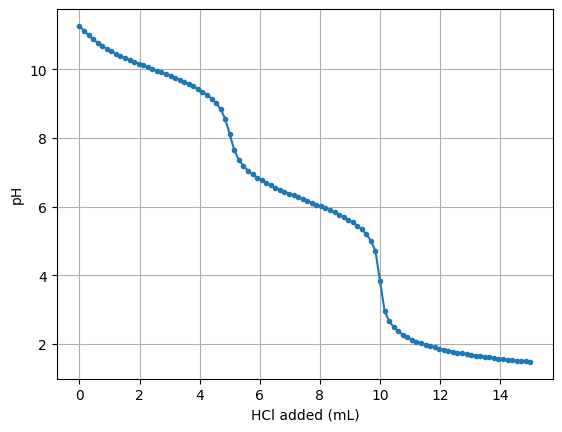

In [7]:
# pH vs. HCl added
import matplotlib.pyplot as plt
plt.figure()
plt.plot(list_v_hcl*1000, df_summary['pH'], '.-')
plt.xlabel('HCl added (mL)')
plt.ylabel('pH')
plt.grid()
plt.show()

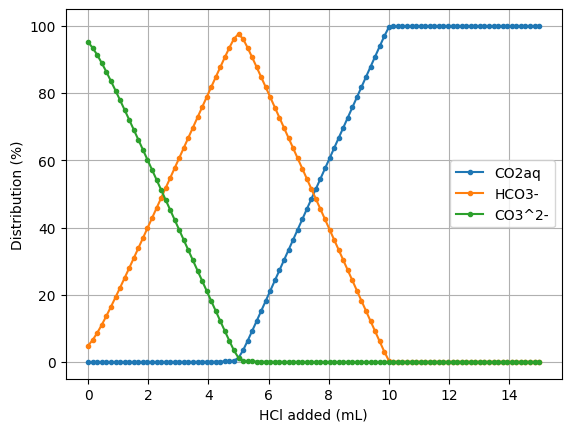

In [8]:
# distribution of carbonate species
plt.figure()
plt.plot(list_v_hcl*1000, df_dist_C['CO2aq'], '.-', label='CO2aq')
plt.plot(list_v_hcl*1000, df_dist_C['HCO3-'], '.-', label='HCO3-')
plt.plot(list_v_hcl*1000, df_dist_C['CO3^2-'], '.-', label='CO3^2-')
plt.xlabel('HCl added (mL)')
plt.ylabel('Distribution (%)')
plt.grid()
plt.legend()
plt.show()